In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import random

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
X_train, X_test = x_train/255.0, x_test/255.0

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

d:\Programming\my_python\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)

training = model.fit(X_train, y_train,
                    epochs=8,
                    validation_split=0.1,
                    callbacks=[callback]
)

Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9312 - loss: 0.2341 - val_accuracy: 0.9693 - val_loss: 0.0991
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9682 - loss: 0.1024 - val_accuracy: 0.9775 - val_loss: 0.0788
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9771 - loss: 0.0726 - val_accuracy: 0.9783 - val_loss: 0.0748
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9829 - loss: 0.0547 - val_accuracy: 0.9785 - val_loss: 0.0729
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9856 - loss: 0.0441 - val_accuracy: 0.9803 - val_loss: 0.0677
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9877 - loss: 0.0367 - val_accuracy: 0.9832 - val_loss: 0.0613
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9889 - loss: 0.0326 - val_accuracy: 0.9813 - val_loss: 0.0737
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9907 - loss: 0.027

In [7]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9810 - loss: 0.0693
Final Test Accuracy: 98.10%


4877
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


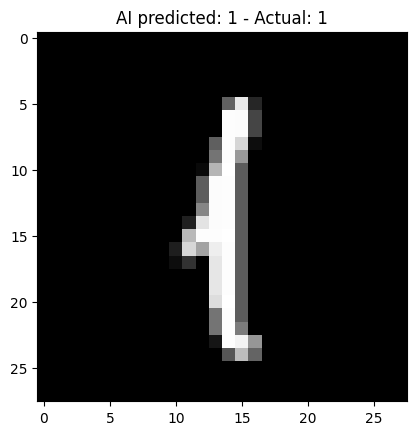

Confidence Level: 99.99%


In [8]:
random_idx = random.randint(0, len(X_test) - 1)
print(random_idx)

img_idx = X_test[random_idx]
lbl_idx = y_test[random_idx]

predictions_probs = model.predict(img_idx.reshape(1, 28, 28))
predicted_label = np.argmax(predictions_probs)

plt.imshow(img_idx, cmap='gray')
plt.title(f"AI predicted: {predicted_label} - Actual: {lbl_idx}")
plt.axis=('off')
plt.show()

confidence = predictions_probs[0][predicted_label]
print(f"Confidence Level: {confidence * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


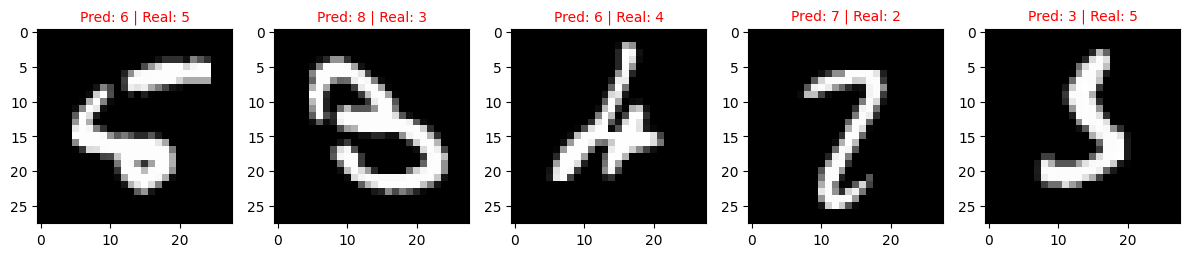

In [9]:
mistakes_found = 0
all_predictions = model.predict(X_test)
all_predicted_labels = np.argmax(all_predictions, axis=1)

plt.figure(figsize=(12, 4))

for i in range(len(X_test)):
    if all_predicted_labels[i] != y_test[i]:
        mistakes_found += 1
        
        plt.subplot(1, 5, mistakes_found)
        plt.imshow(X_test[i], cmap='gray')
        plt.title(f"Pred: {all_predicted_labels[i]} | Real: {y_test[i]}", color='red', fontsize=10)
        plt.axis='off'

        if mistakes_found == 5:
            break

plt.tight_layout()
plt.show()
